# 1 · Cómo se evalúa + baselines (estadísticos y de modelos)

Antes de los modelos profundos, fijamos **cómo se mide** y los baselines. Van en
orden de complejidad creciente: primero los **estadísticos** (z-score, Mahalanobis —
sin aprendizaje), después los **de modelos** (Isolation Forest, One-Class SVM).

**Métrica principal: PR-AUC** (área Precision-Recall, libre de umbral). Razones:
- El **F1 con umbral fijo engaña**: el umbral se calibra en val (tasa ~6%) pero en test
  la tasa salta a ~27% (sequía 2022/23) → un corte absoluto marca casi todo → F1 ≈ tasa
  base para todos.
- Todo se reporta **multi-seed (media ± std)** porque los modelos profundos varían.

**Política de semillas (para que las comparaciones sean justas):**
- Evaluar **cualquier modelo** = **10 semillas** (`SEEDS`), reportando media ± desvío.
- Los modelos **deterministas** (One-Class SVM) no tienen semilla → std = 0; los
  estocásticos (VAE, AE, DAE, **Isolation Forest**) sí varían y muestran su ±std.
- Los **barridos** (búsqueda de HP en nb 3, ablación de features en nb 6) usan **5
  semillas** — es un screening de muchas configuraciones, se declara donde se hace.

`lab.metrics(scores, y)` devuelve PR-AUC, ROC-AUC, precisión@k y recall al top-10%;
`lab.tabla(resultados)` es la **presentación estándar** del proyecto (fila = modelo,
métricas `media±std`).

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)


soja  train: (6143, 65) | test anómalas: 251
maíz  train: (8082, 65) | test anómalas: 344


## 1.1 · Baselines estadísticos: z-score y Mahalanobis
Puramente estadísticos, sin aprendizaje ni redes; solo necesitan media (y, en Mahalanobis,
covarianza) del train normal. Ambos son **deterministas** (sin semilla → ±0.000).

- **Z-score multivariado** (`ZScoreDetector`): `z=(x−media)/desvío` por feature; el score es
  el promedio (`mean`) o el máximo (`max`) de `|z|` entre las 54 features. No ve correlaciones.
- **Mahalanobis** (`MahalanobisDetector`): distancia con la **covarianza completa**
  (encogimiento Ledoit-Wolf para invertirla estable con 54 features) — "z-score con
  correlaciones".

Los resultados se muestran con `lab.tabla`, la **presentación estándar del proyecto** (una
fila por modelo, métricas `media±std`).

In [3]:
estadisticos = {
    "ZScore (mean)": [lab.metrics(ZScoreDetector(agg="mean").fit(ds.X_train)
                                  .score_samples(ds.X_test), ds.y_test)],
    "ZScore (max)":  [lab.metrics(ZScoreDetector(agg="max").fit(ds.X_train)
                                  .score_samples(ds.X_test), ds.y_test)],
    "Mahalanobis":   [lab.metrics(MahalanobisDetector(shrinkage=None).fit(ds.X_train)
                                  .score_samples(ds.X_test), ds.y_test)],
}
lab.tabla(estadisticos)

,pr_auc,roc_auc
ZScore (mean),0.576±0.000,0.714±0.000
Mahalanobis,0.397±0.000,0.659±0.000
ZScore (max),0.349±0.000,0.647±0.000


## 1.2 · Baselines de modelos: Isolation Forest y One-Class SVM
El siguiente escalón: modelos que *aprenden* la región normal.

- **Isolation Forest** — ensamble de árboles que aísla puntos raros; estocástico, así que va
  **multi-seed** (3 semillas acá para el "Run all"; el estudio usa 10). El único HP con
  efecto real fue `max_features=0.3`.
- **One-Class SVM** — frontera que envuelve a los normales; con kernel **RBF** es no lineal.
  Comparamos RBF vs lineal para ver que la no-linealidad importa (determinista).

In [4]:
modelos = {
    "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                random_state=s).fit(ds.X_train).score_samples(ds.X_test), ds.y_test)
                for s in SEEDS[:3]],
    "OCSVM (rbf)":    [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                   .fit(ds.X_train).score_samples(ds.X_test), ds.y_test)],
    "OCSVM (linear)": [lab.metrics(OneClassSVMDetector(kernel="linear", nu=0.1)
                                   .fit(ds.X_train).score_samples(ds.X_test), ds.y_test)],
}
lab.tabla(modelos)

,pr_auc,roc_auc
IForest,0.548±0.025,0.697±0.018
OCSVM (rbf),0.506±0.000,0.700±0.000
OCSVM (linear),0.279±0.000,0.520±0.000


**El kernel lineal fracasa** y el **RBF es competitivo con el IForest**: la frontera no
lineal es imprescindible. Y el **z-score (mean)** de 1.1, sin aprender nada, ya juega en la
misma liga que el IForest (lo interpretamos en 1.5).

## 1.3 · Comparación de todos los baselines (soja y maíz)
Todos los baselines juntos, en la tabla estándar. Acá **solo comparamos baselines entre sí**
(el listón a superar); los modelos de reconstrucción del nb 2 en adelante se miden contra
este piso en sus propios notebooks.

In [5]:
def baselines_dict(dset):
    return {
        "ZScore (mean)": [lab.metrics(ZScoreDetector(agg="mean").fit(dset.X_train)
                                      .score_samples(dset.X_test), dset.y_test)],
        "ZScore (max)":  [lab.metrics(ZScoreDetector(agg="max").fit(dset.X_train)
                                      .score_samples(dset.X_test), dset.y_test)],
        "Mahalanobis":   [lab.metrics(MahalanobisDetector(shrinkage=None).fit(dset.X_train)
                                      .score_samples(dset.X_test), dset.y_test)],
        "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                    random_state=s).fit(dset.X_train).score_samples(dset.X_test), dset.y_test)
                    for s in SEEDS[:3]],
        "OCSVM (rbf)": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                    .fit(dset.X_train).score_samples(dset.X_test), dset.y_test)],
    }

res = {"soja": baselines_dict(ds), "maíz": baselines_dict(dsm)}
lab.tabla(res["soja"])

,pr_auc,roc_auc
ZScore (mean),0.576±0.000,0.714±0.000
IForest,0.548±0.025,0.697±0.018
OCSVM (rbf),0.506±0.000,0.700±0.000
Mahalanobis,0.397±0.000,0.659±0.000
ZScore (max),0.349±0.000,0.647±0.000


Y en maíz:

In [6]:
lab.tabla(res["maíz"])

,pr_auc,roc_auc
IForest,0.554±0.012,0.681±0.001
ZScore (mean),0.530±0.000,0.661±0.000
OCSVM (rbf),0.457±0.000,0.618±0.000
Mahalanobis,0.360±0.000,0.571±0.000
ZScore (max),0.314±0.000,0.533±0.000


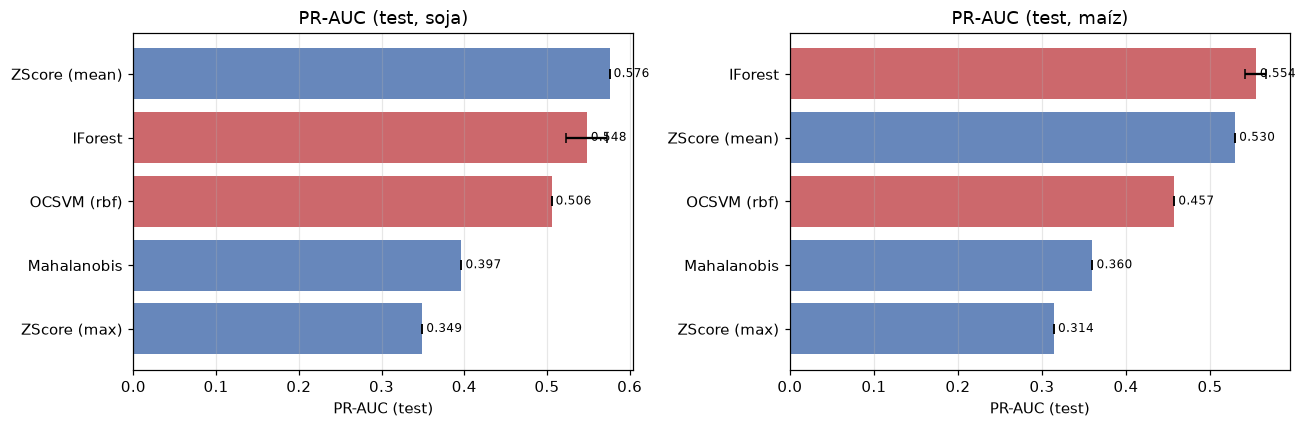

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nombre, r) in zip(axs, res.items()):
    lab.plot_leaderboard(lab.leaderboard(r), ax=ax, titulo=f"PR-AUC (test, {nombre})")
plt.tight_layout(); plt.show()

## 1.4 · Matrices de confusión de los baselines
El PR-AUC mide el *ranking* (libre de umbral). Para una matriz de confusión hace falta un
**corte**, y un umbral absoluto no transfiere entre períodos (los scores se corren hacia
arriba en 2021–24 → un corte fijo marca ~70% del test). Por eso re-umbralizamos sobre el
**propio test** al top-tasa real (~27%, `q="base"`), para **todos los baselines** (soja):

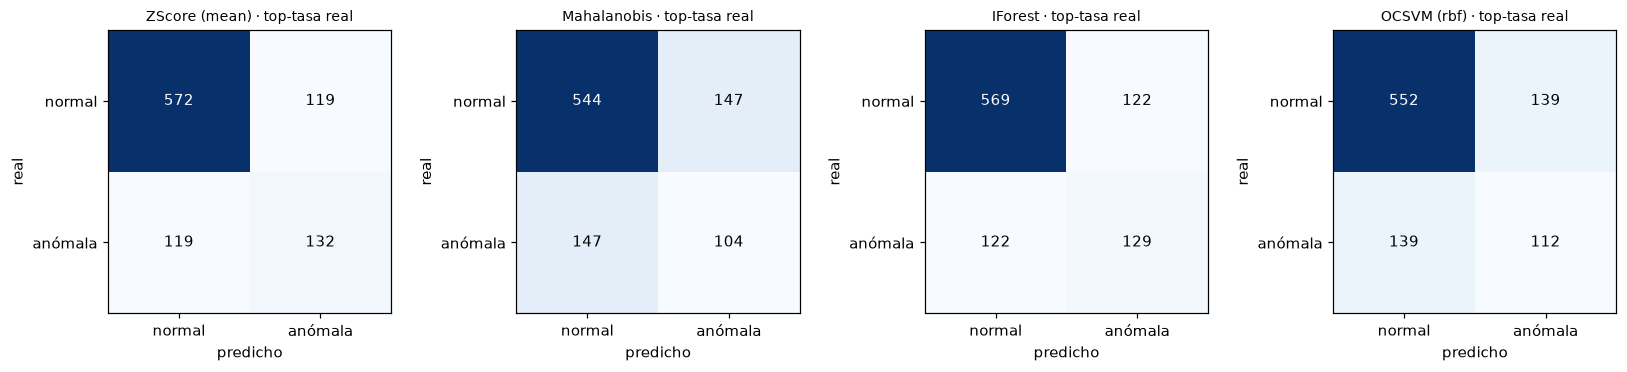

In [8]:
scores_conf = {
    "ZScore (mean)": ZScoreDetector(agg="mean").fit(ds.X_train).score_samples(ds.X_test),
    "Mahalanobis":   MahalanobisDetector(shrinkage=None).fit(ds.X_train).score_samples(ds.X_test),
    "IForest":       IsolationForestDetector(n_estimators=200, max_features=0.3,
                                             random_state=42).fit(ds.X_train).score_samples(ds.X_test),
    "OCSVM (rbf)":   OneClassSVMDetector(kernel="rbf", nu=0.1).fit(ds.X_train).score_samples(ds.X_test),
}
fig, axs = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, (nombre, sc) in zip(axs, scores_conf.items()):
    lab.confusion_top(sc, ds.y_test, "base", ax=ax, titulo=nombre)
plt.tight_layout(); plt.show()

## 1.5 · Interpretación + por qué no hay validación

**El z-score (mean) queda a la par del Isolation Forest** (en soja incluso lo supera
levemente) pese a no aprender nada: la señal detectable es la **sequía**, que corre muchas
features climáticas a la vez → promediar `|z|` es casi un "índice de sequía" a mano. El `max`
se hunde (una sola feature rara ≠ anomalía de rinde), y **Mahalanobis queda por debajo**:
des-pondera justo las direcciones de mayor varianza (donde vive la firma de sequía). Lección
de siempre: *rareza climática ≠ anomalía de rinde*.

**Por qué no hay validación:** probamos un val 2018–2020 y resultó **ciego** — sus anomalías
son de años sin sequía grande (sin firma climática) → PR-AUC ≈ tasa base para todos, no
discriminaba nada. Por eso (1) el val se pliega al train y (2) las comparaciones y la
selección de HP (nb 3) se ilustran en test, con el *data snooping* declarado. La confianza en
el modelo final viene de la **consistencia entre cultivos** y la **varianza mínima entre
semillas**, no de un número puntual.

**Checklist de baselines cerrado** (IForest, OCSVM, z-score, Mahalanobis). **Baseline a
superar: el z-score (mean) / IForest**; los próximos notebooks lo intentan con modelos de
reconstrucción.